**Sprint 2**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as lst

#connects to our shared google drive folder that has the csv. Professor I have added you to the shared drive so you can run the code
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/Shareddrives/CS133 Group 6/CS 133 Project Group 6/diabetes_dataset.csv'
df= pd.read_csv(path)
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [ ]:
df.dtypes

,0
year,int64
gender,object
age,float64
location,object
race:AfricanAmerican,int64
race:Asian,int64
race:Caucasian,int64
race:Hispanic,int64
race:Other,int64
hypertension,int64


In [ ]:
#check if the there are people with multiple races
(df['race:AfricanAmerican']+df['race:Asian']+df['race:Hispanic']+df['race:Caucasian']+df['race:Other']).max()

1

In [ ]:
#Makes a column called race to make it easier to groupby race
def race_to_col(row):
  if row['race:AfricanAmerican'] == 1:
    return 'African American'
  elif row['race:Asian'] == 1:
    return 'Asian'
  elif row['race:Hispanic'] == 1:
    return 'Hispanic'
  elif row['race:Caucasian'] == 1:
    return 'Caucasian'
  else:
    return 'Other'

df['race'] = df.apply(race_to_col, axis='columns')
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,race
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,Other
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Asian
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,Other
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,Caucasian
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,African American


In [ ]:
print(df['smoking_history'].unique())
print(df['gender'].unique())
print(df['location'].unique())

['never' 'not current' 'current' 'No Info' 'ever' 'former']
['Female' 'Male' 'Other']
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Guam' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Puerto Rico' 'Rhode Island'
 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'United States'
 'Utah' 'Vermont' 'Virgin Islands' 'Virginia' 'Washington' 'West Virginia'
 'Wisconsin' 'Wyoming']


In [ ]:
#Doing it as a check but no rows dropped
df.dropna()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,race
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,Other
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Asian
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,Other
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,Caucasian
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,African American
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,Other
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Asian
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,Asian
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,African American


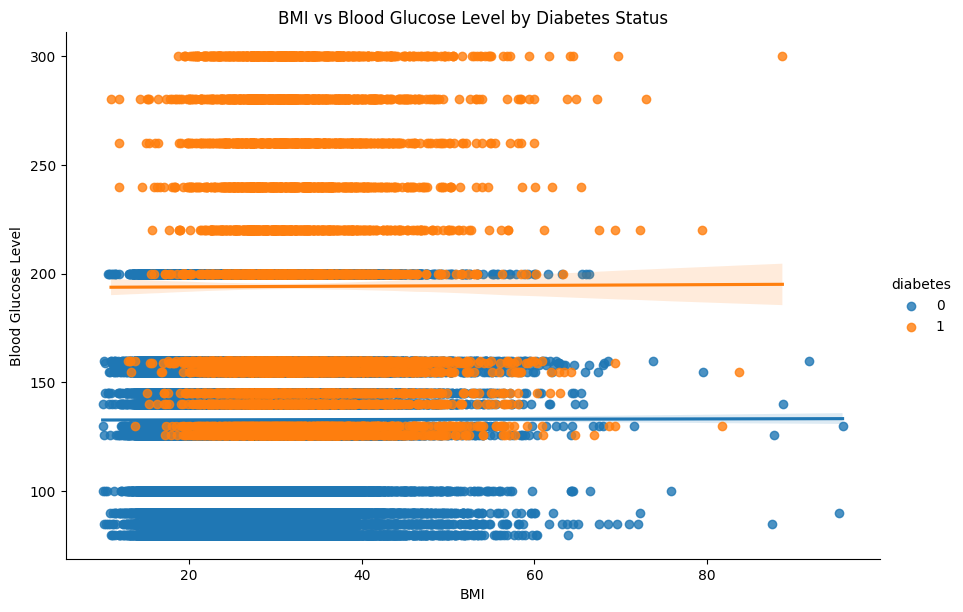

In [ ]:
# Plot 1, regression plot that answers: "Does higher BMI correlate with higher blood glucose, and is that linked to diabetes?"
# The lmplot shows two trend lines — one for diabetic (1) and one for non-diabetic (0) individuals.
# Both lines trend upward, meaning higher BMI is associated with higher blood glucose levels.
# The diabetic group's trend line sits higher overall, indicating that at any given BMI,
# diabetic individuals tend to have elevated blood glucose compared to non-diabetics.
# This suggests BMI is a meaningful risk factor for diabetes.
sns.lmplot(
    data=df,
    x='bmi',
    y='blood_glucose_level',
    hue='diabetes',
    height=6,
    aspect=1.5
)
lst.title("BMI vs Blood Glucose Level by Diabetes Status");
lst.xlabel('BMI');
lst.ylabel('Blood Glucose Level');

Text(0.5, 1.05, 'relationship between smoking and diabetes for each race')

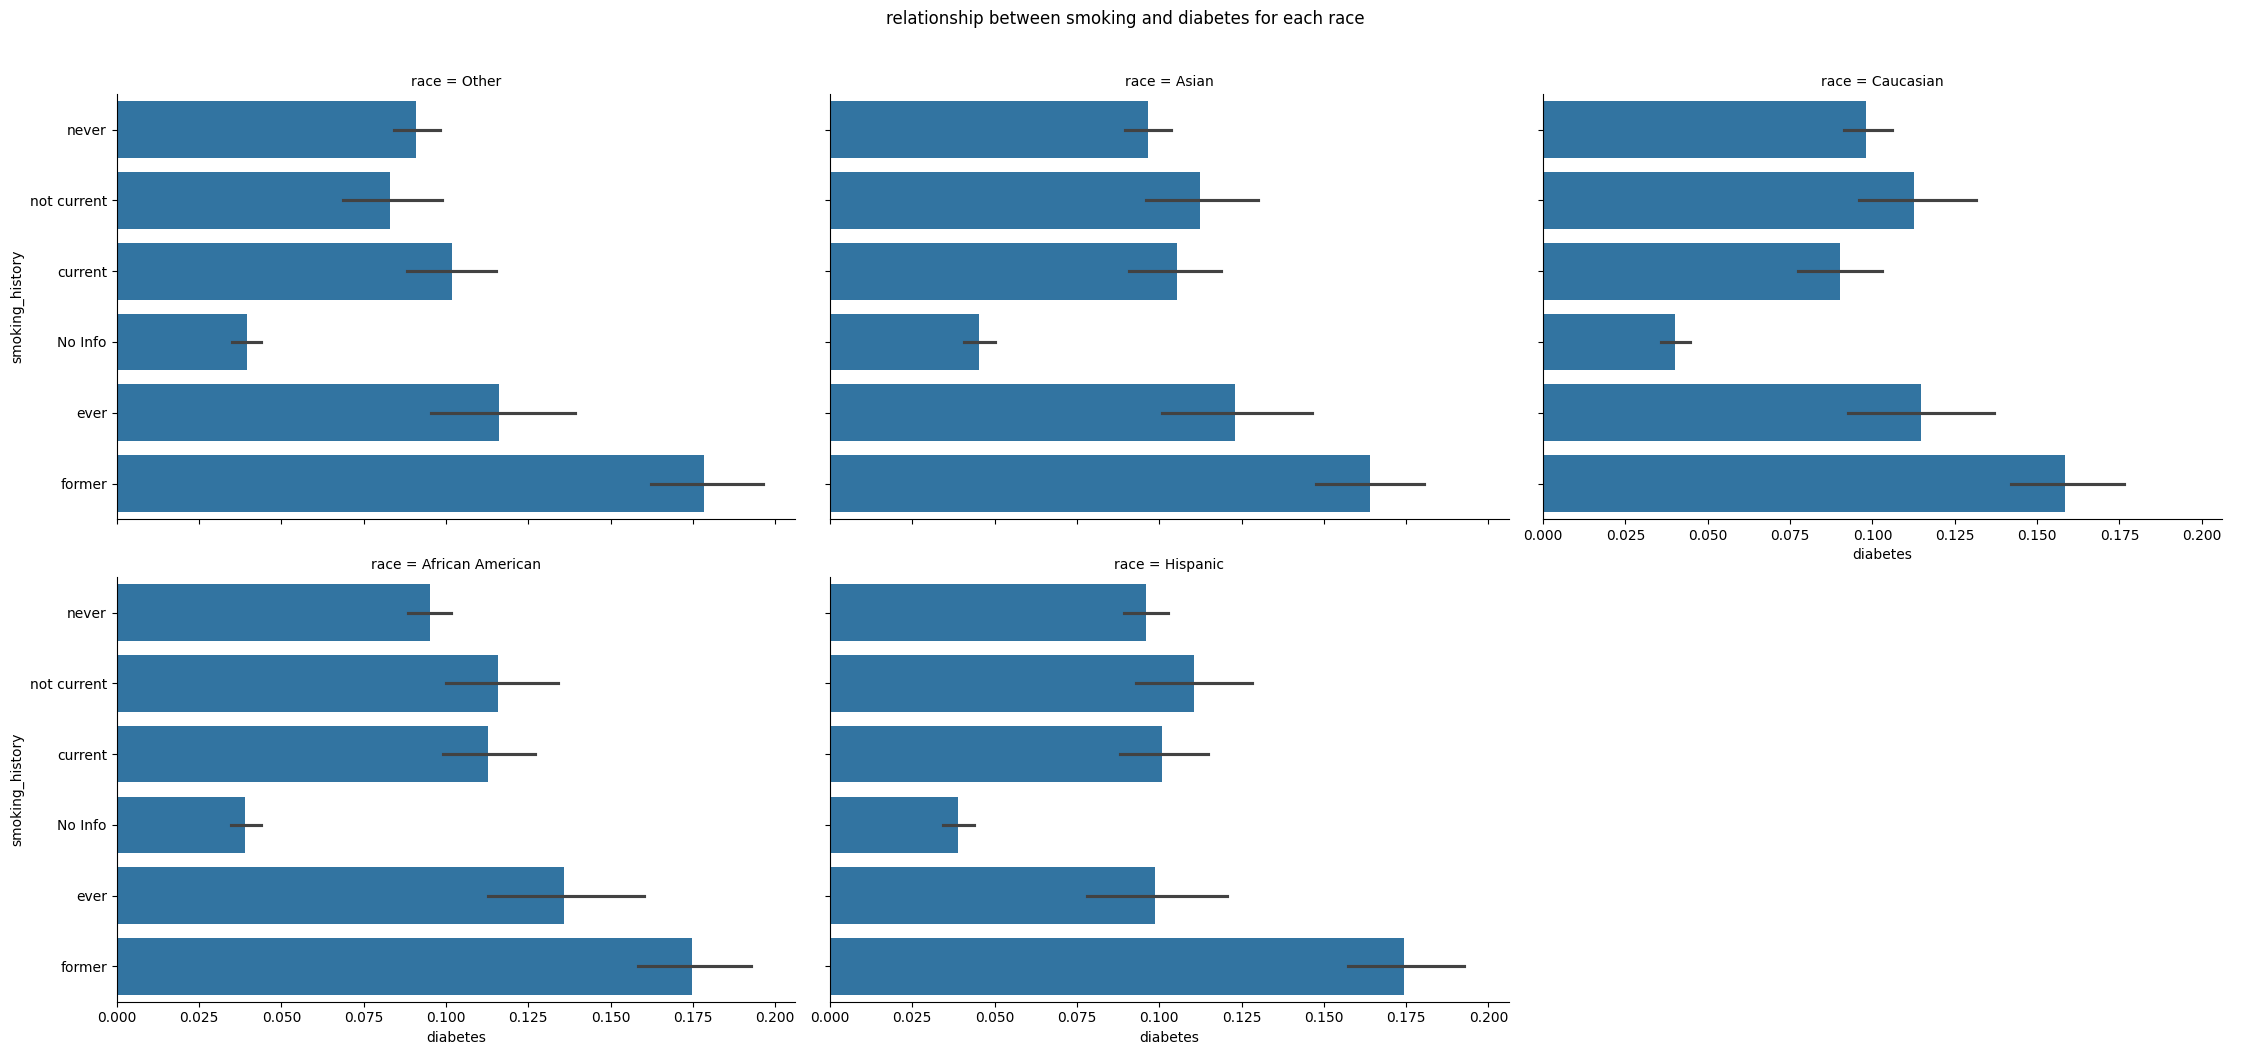

In [ ]:
# Plot 2, small multiples catplot for the relationship between smoking and diabetes for each race
# The catplot displays bar charts for each racial group, showing the average diabetes rate
# across different smoking history categories (never, current, former, etc.).
# Across all racial groups, former smokers consistently show the highest proportion of diabetes,
# and any smoking history generally correlates with a higher diabetes rate compared to never smokers.
# Importantly, this pattern holds across all races, meaning race itself is not a major factor —
# rather, smoking behavior is what drives the increased risk.
# This suggests that quitting or avoiding smoking is one way to reduce diabetes risk.
sns.catplot(
    data=df,
    kind='bar',
    x='diabetes',
    y='smoking_history',
    col='race',
    col_wrap=3,
    height=5,
    aspect=1.5
).fig.suptitle('relationship between smoking and diabetes for each race', y=1.05)

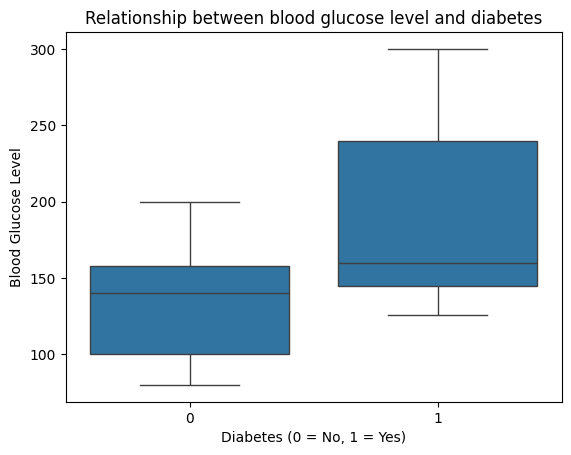

In [ ]:
# Plot 3, categorical (box plot) that answers: "What can someone do to reduce risk of diabetes?"
# The boxplot compares the distribution of blood glucose levels between non-diabetic (0) and diabetic (1) individuals.
# The diabetic group has a noticeably higher median and a wider spread of blood glucose values.
# Since blood glucose is directly controllable through diet, exercise, and medication,
# this plot suggests that keeping blood glucose levels low is one of the most actionable
# ways a person can reduce their risk of developing diabetes.
sns.boxplot(
    data=df,
    x='diabetes',
    y='blood_glucose_level'
)
lst.title('Relationship between blood glucose level and diabetes');
lst.xlabel('Diabetes (0 = No, 1 = Yes)');
lst.ylabel('Blood Glucose Level');
# this shows that higher blood glucose levels oftentiems lead to diabetes